# A walk through feynsage

This notebook goes through the package one step at a time, in the same order as the lecture notes
*Feynman integrals at one loop*. Every step has the code, its output and a diagram.

1. Momenta and a first diagram
2. Spanning trees, 2-forests and the Symanzik polynomials $\mathcal U$, $\mathcal F$
3. The two-loop kite: three independent ways to get $\mathcal U$
4. Zero sectors (Lee's criterion)
5. Integration-by-parts identities
6. Laporta reduction to master integrals
7. The same reduction with finite fields
8. Closed one-loop formulas and the $\epsilon$ expansion
9. Dirac traces with FORM
10. Plots in the style of the notes
11. A real number: the lifetime of the neutral pion
12. One-loop tensor integrals, the Package-X way
13. The four examples of the lecture notebook
14. The short front end: `family`, `ibp_reduce`, `diagram`, `quick_plot`
15. Poles from soft photons, boxes in dilogarithms, a zero Gram determinant
16. Exact IBP reduction made fast: `method="trimmed"`
17. $\mathcal U$ and $\mathcal F$ beyond the lecture notebook: a three-loop box, three ways
18. QED from Chluba's thesis: Compton, double Compton and the infrared divergence

Run it with the SageMath kernel from the top folder of the repository or from `examples/`.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..') if os.path.basename(os.getcwd()) == 'examples' else os.getcwd())
from feynsage import *
from feynsage.plotting import quick_plot, set_theme, draw_panels, draw_sectors, draw_graph, curves, mb_plane, PINK, BLUE
import matplotlib.pyplot as plt
from feynsage.oneloop import *
from IPython.display import Math, display
set_theme()
%matplotlib inline

## 1. Momenta and a first diagram

A momentum is a dictionary: `mom(l=1, p=-1)` is $\ell - p$. The `Kinematics` object fixes the external
momenta, the invariants and the scalar products and whether we are in Euclidean space.

Our first diagram is the bubble with two different masses. The external momentum $p$ enters at vertex A
and leaves at vertex B. Each internal line is `(vertex, vertex, mass^2)`.

lines: 2  vertices: 2  loops L = N - V + 1 = 1


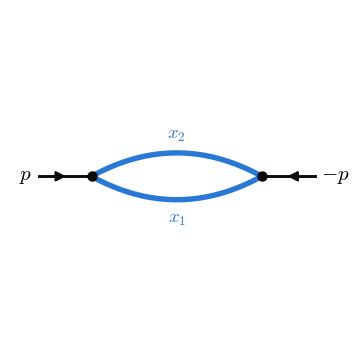

In [2]:
km = Kinematics(['p'], ['pp', 'ma', 'mb'], {('p','p'): 'pp'}, euclidean=True)
bubble = FeynmanGraph([('A','B','ma'), ('A','B','mb')], {'A': mom(p=1), 'B': mom(p=-1)}, km)
print("lines:", bubble.N, " vertices:", bubble.V, " loops L = N - V + 1 =", bubble.L)
bubble.plot();

Massive lines are drawn thick and blue. The label $x_i$ on a line is its Feynman parameter, the same
$x_i$ that appears in $\mathcal U$ and $\mathcal F$.

## 2. Spanning trees, 2-forests, $\mathcal U$ and $\mathcal F$

The rules of the lecture:

* a **spanning tree** touches every vertex and has no loop. Remove $L$ lines to get one.
  $\mathcal U$ is the sum over spanning trees of the product of the $x_i$ of the *removed* lines;
* a **2-forest** is two trees. Remove $L + 1$ lines. $\mathcal F_0$ is the sum over 2-forests of the
  product of the removed $x_i$ times $P^2$, where $P$ is the total external momentum entering one of the two trees;
* $\mathcal F = \mathcal F_0 + \mathcal U \sum_i x_i m_i^2$.

For the bubble, removing either line leaves a tree and removing both leaves two single vertices.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

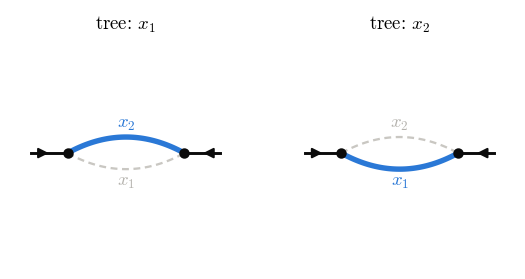

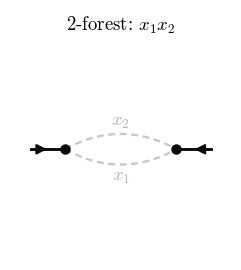

In [3]:
def xs(rem):
    return "$" + "".join("x_{%d}" % (i + 1) for i in rem) + "$"

trees = bubble.spanning_trees()
draw_panels(bubble, trees, titles=["tree: " + xs(r) for r in trees], momenta=False);
forests = bubble.two_forests()
draw_panels(bubble, [r for r, comp in forests], titles=["2-forest: " + xs(r) for r, comp in forests], momenta=False);
eq(r"\mathcal{U}", bubble.U())
eq(r"\mathcal{F}", bubble.F())

The grey dashed lines are the removed ones. $\mathcal U = x_1 + x_2$ has one term per tree and
$\mathcal F_0 = p^2 x_1 x_2$ comes from the one 2-forest, since the momentum entering vertex A is $p$.

## 3. The two-loop kite

Vertices L, T, B, R. The momentum $p$ enters at L and leaves at R and line 5 joins T and B.
We read $\mathcal U$ three ways and check that they agree:

1. from the spanning trees (the rule above);
2. from the Kirchhoff matrix-tree theorem (a determinant of the graph Laplacian);
3. from the matrix method $\mathcal U = \det M$, after routing loop momenta through a cycle basis.

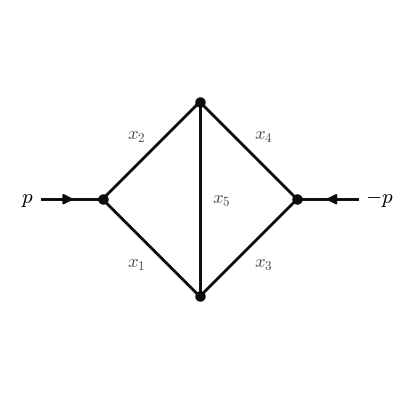

In [4]:
kin = Kinematics(['p'], ['pp'], {('p','p'): 'pp'}, euclidean=True)
kite = FeynmanGraph([('L','B',0), ('L','T',0), ('B','R',0), ('T','R',0), ('T','B',0)],
                    {'L': mom(p=1), 'R': mom(p=-1)}, kin)
kite.plot(figsize=(3.2, 3.2));

8 spanning trees, each with L = 2 lines removed


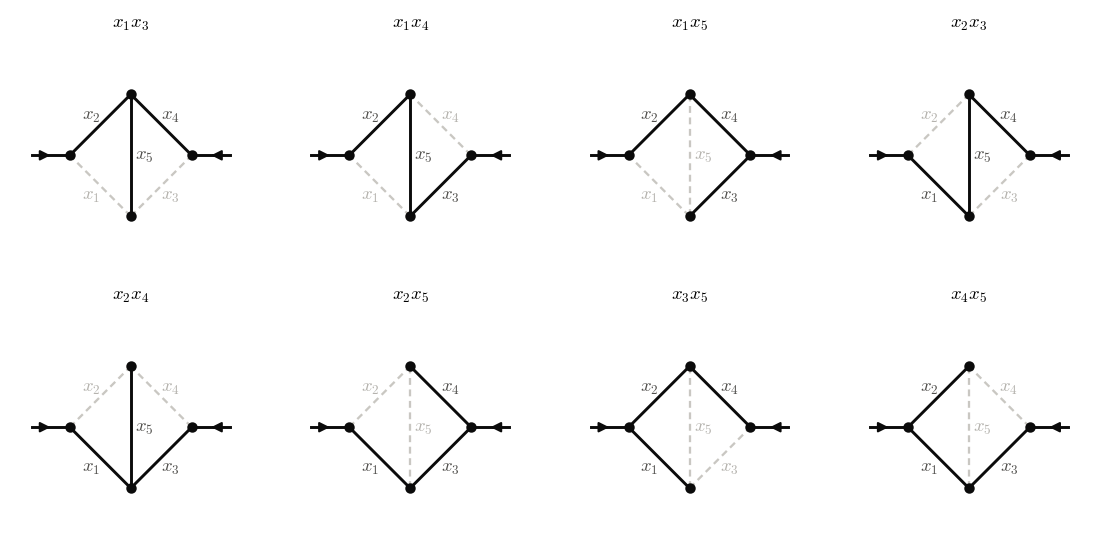

In [5]:
trees = kite.spanning_trees()
print(len(trees), "spanning trees, each with L = 2 lines removed")
draw_panels(kite, trees, titles=[xs(r) for r in trees], momenta=False, ncols=4);

10 2-forests; the title gives the removed lines and the momentum entering one tree


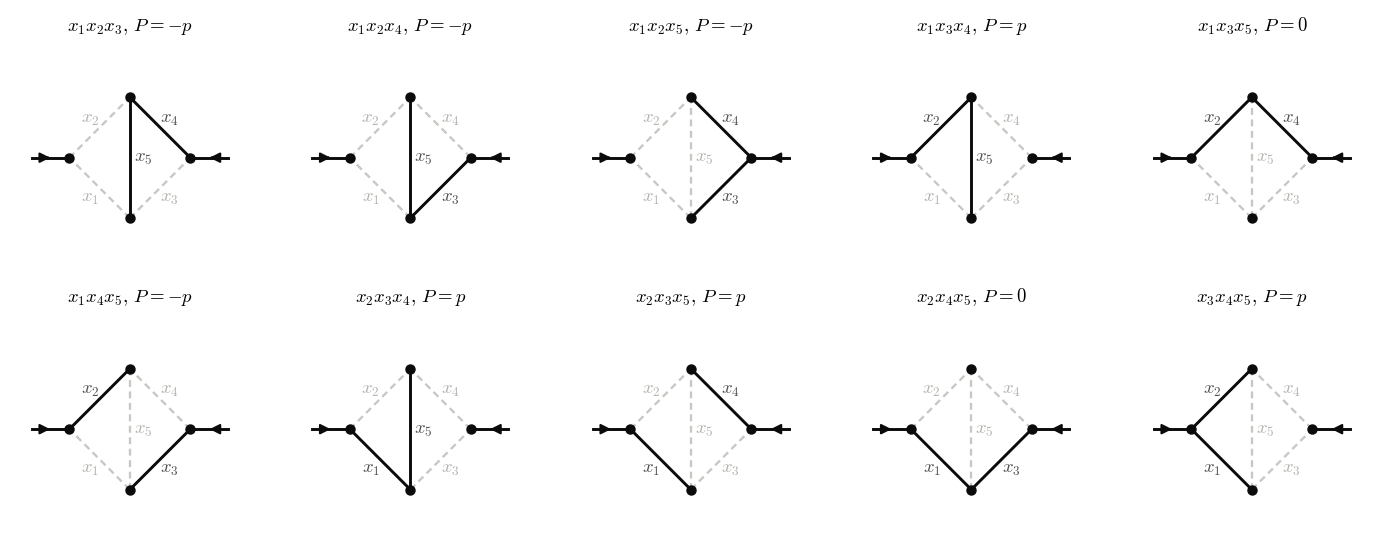

In [6]:
forests = kite.two_forests()
print(len(forests), "2-forests; the title gives the removed lines and the momentum entering one tree")
def entering(comp):
    tot = {}
    for v in comp:
        for k, c in kite.ext.get(v, {}).items():
            tot[k] = tot.get(k, 0) + c
    tot = {k: c for k, c in tot.items() if c}
    return "0" if not tot else "+".join(("" if c == 1 else "-" if c == -1 else str(c)) + k for k, c in tot.items())
draw_panels(kite, [r for r, c in forests],
            titles=[xs(r) + ", $P=" + entering(c) + "$" for r, c in forests], momenta=False, ncols=5);

2-forests in which one tree gets no external momentum ($P = 0$) do not contribute to $\mathcal F_0$.
Now the three ways of computing $\mathcal U$ and $\mathcal F$ from the trees and from the matrix method:

In [7]:
U, F = kite.U(), kite.F()
props, loops = kite.family()
fam = IntegralFamily('kite', loops, kin, props)
Um, Fm = fam.UF()
eq(r"\mathcal{U}", U)
eq(r"\mathcal{F}", F)
print("Kirchhoff U = trees:", kite.U_kirchhoff() == U, "   det M: U same:", kite.R(str(Um)) == U, "  F same:", kite.R(str(Fm)) == F)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Kirchhoff U = trees: True    det M: U same: True   F same: True


## 4. Zero sectors

Setting some indices to 0 gives a *sector*. An index 0 means the propagator is absent, so in the
picture that line is **shrunk to a point** and its two end vertices merge (this is different from the
spanning trees above, where lines are deleted). A sector whose integrals are scaleless is zero in
dimensional regularisation. Lee's criterion decides this from $\mathcal U + \mathcal F$ alone: the sector is
zero if and only if a vector $k$ exists with $\langle k, e\rangle = 1$ for every exponent vector $e$ of
$\mathcal U + \mathcal F$.

Here is the massless kite with $p^2 = q^2$ in Minkowski space, the family used for the reduction below.
We list every sector with 3 lines and draw all of them.

In [8]:
kq = Kinematics(['q'], [], {('q','q'): 1}, euclidean=False)          # q^2 = 1, the only scale
props_q = [(mom(l1=1),0), (mom(l1=1,q=1),0), (mom(l1=1,l2=1),0), (mom(l1=1,l2=1,q=1),0), (mom(l2=1),0)]
famq = IntegralFamily('kite', ['l1','l2'], kq, props_q)
from itertools import combinations
three = [s for s in [tuple(1 if i in c else 0 for i in range(5)) for c in combinations(range(5), 3)]]
zero = [s for s in three if famq.is_zero_sector(s)]
for s in three:
    print(s, "zero" if s in zero else "non-zero")

(1, 1, 1, 0, 0) zero
(1, 1, 0, 1, 0) zero
(1, 1, 0, 0, 1) zero
(1, 0, 1, 1, 0) zero
(1, 0, 1, 0, 1) zero
(1, 0, 0, 1, 1) non-zero
(0, 1, 1, 1, 0) zero
(0, 1, 1, 0, 1) non-zero
(0, 1, 0, 1, 1) zero
(0, 0, 1, 1, 1) zero


To draw a sector we need to know which propagator is which line. We write down a kite graph with the
lines in the order of the propagators and check that it has the same $\mathcal U$ and $\mathcal F$ as the
family. If the order were wrong, the polynomials would not match. Following the momentum through the
vertices, $\ell_1$ runs on L–B, $\ell_1 + q$ on L–T, $\ell_1 + \ell_2$ on B–R, $\ell_1 + \ell_2 + q$ on T–R and
$\ell_2$ on T–B.

same U: True   same F: True


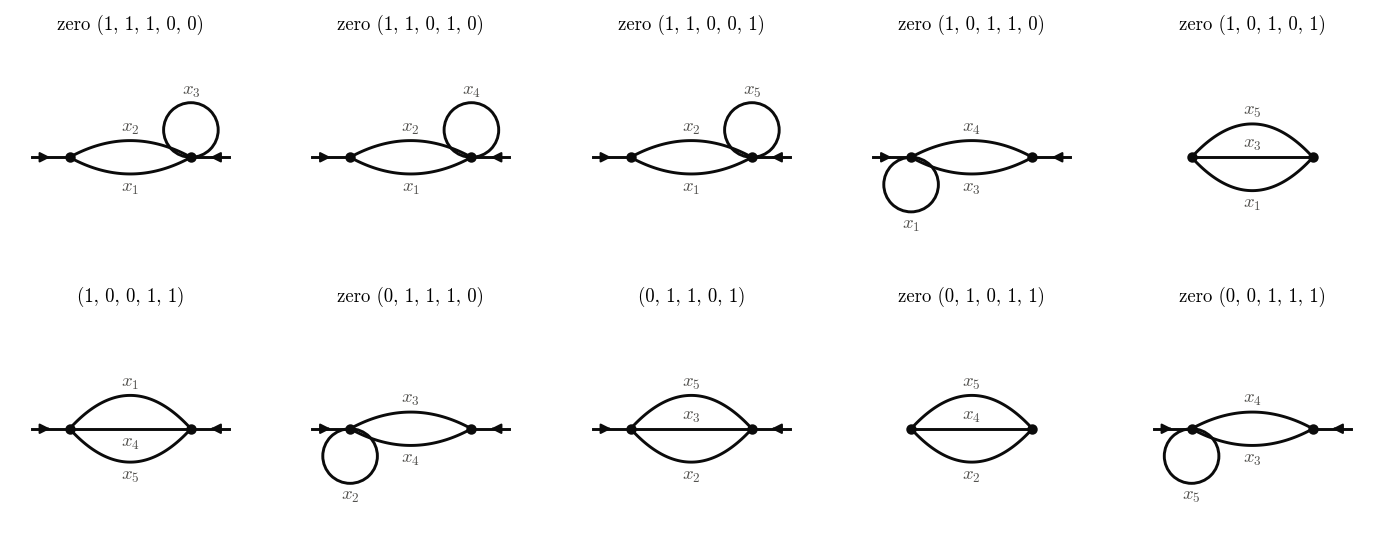

In [9]:
kiteq = FeynmanGraph([('L','B',0), ('L','T',0), ('B','R',0), ('T','R',0), ('T','B',0)],
                     {'L': mom(q=1), 'R': mom(q=-1)}, kq)
# check that this graph has the same U and F as the family, so the line order is right
Ug, Fg = kiteq.U(), kiteq.F()
Uf, Ff = famq.UF()
print("same U:", kiteq.R(str(Uf)) == Ug, "  same F:", kiteq.R(str(Ff)) == Fg)
draw_sectors(kiteq, three, titles=[("zero " if s in zero else "") + str(s) for s in three], momenta=False, ncols=5);

A zero sector always contains a massless loop that sits on a single vertex or that no external momentum
flows through: a scaleless tadpole. The non-zero ones are those where $q$ still flows through every loop.

## 5. Integration-by-parts identities

For the one-loop bubble with equal masses in Minkowski space,
$J(a_1, a_2) = \int [d\ell]\, D_1^{-a_1} D_2^{-a_2}$ with $D_1 = \ell^2 - m^2$ and $D_2 = (\ell - p)^2 - m^2$ ($m^2 = 1$).
`fam.ibp(a)` returns the $L(L+E) = 2$ identities $\int \partial_\ell \cdot v \,(\dots) = 0$ for $v = \ell, p$,
as dictionaries {index vector: coefficient}.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

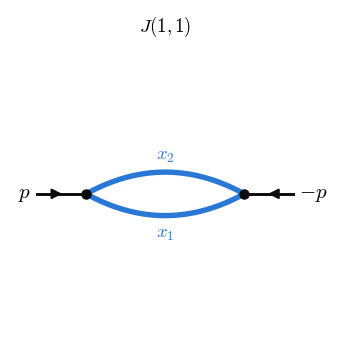

In [10]:
kb = Kinematics(['p'], ['s'], {('p','p'): 's'}, euclidean=False)
d, s = kb.R.gens()
bub = IntegralFamily('bub', ['l'], kb, [(mom(l=1), 1), (mom(l=1, p=-1), 1)])
for k, ident in enumerate(bub.ibp((1, 1))):
    display(Math(r"\text{identity %d:}\quad " % (k + 1) + " + ".join(r"\left(%s\right) J%s" % (latex(c), a) for a, c in ident.items()).replace("+ -", "- ") + " = 0"))
gb = FeynmanGraph([('A','B',1), ('A','B',1)], {'A': mom(p=1), 'B': mom(p=-1)}, kb)
gb.plot(figsize=(2.6, 2.6), title="$J(1,1)$");

## 6. Laporta reduction

`Reducer` generates the identities for many seeds, orders the integrals from complicated to simple and
solves. The symmetry $\ell \to p - \ell$ swaps the two lines. What is left unsolved are the master integrals.
In the pictures a pink dot on a line means one more power of that propagator, as in the notes.

masters: [(0, 1), (1, 1)]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

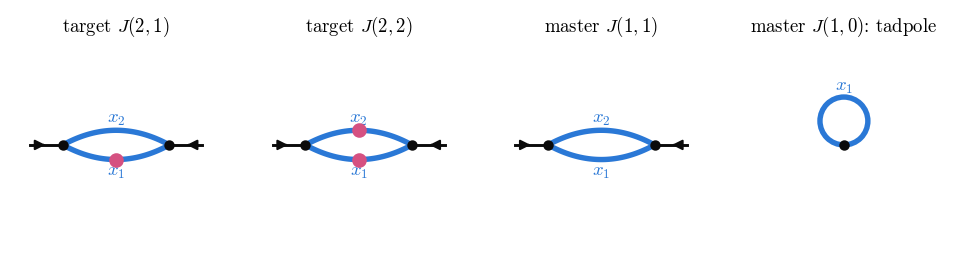

In [11]:
red = Reducer(bub, symmetries=[(1, 0)]).run(rmax=3)
print("masters:", red.masters())
for a in [(2, 1), (2, 2)]:
    display(Math("J%s = " % (a,) + " + ".join(r"\left[%s\right] J%s" % (latex(c.factor()), m) for m, c in red.reduce(a).items())))
fig, axes = plt.subplots(1, 4, figsize=(8, 2))
draw_graph(gb, dots={1: 1}, ax=axes[0], momenta=False, title="target $J(2,1)$")
draw_graph(gb, dots={1: 1, 2: 1}, ax=axes[1], momenta=False, title="target $J(2,2)$")
draw_graph(gb, ax=axes[2], momenta=False, title="master $J(1,1)$")
tad, kept = gb.contract([2])
draw_graph(tad, names=kept, ax=axes[3], momenta=False, title="master $J(1,0)$: tadpole");

These agree with Kira 3.1 (see `tests/test_bubble.sage`).

## 7. The same reduction with finite fields

`reduce_ff` does what FIRE and Kira do. It solves the system numerically modulo large primes at random
values of $d$, keeps only the equations the targets need and rebuilds the rational coefficients by
Thiele interpolation and rational reconstruction. Here it is on the kite, for an integral with nine dots,
compared with the exact reducer on a smaller one.

In [12]:
redq = Reducer(famq, symmetries=[(2,3,0,1,4), (1,0,3,2,4)])
t0 = time.time()
res = reduce_ff(redq, [(3,3,2,3,3), (2,2,1,2,2)], rmax=9, smax=4, verbose=True)
print("finite-field time: %.1f s" % (time.time() - t0))
display(Math("F(2,2,1,2,2) = " + r" \\ + ".join(r"\left[%s\right] F%s" % (latex(c.factor()), m) for m, c in res[(2,2,1,2,2)].items())))

system: 157843 equations, 11462 integrals (1.0s)


primes used: 3, total 2.7s
finite-field time: 2.8 s


<IPython.core.display.Math object>

exact reducer (smaller seed range) time: 7.8 s
same coefficients: True


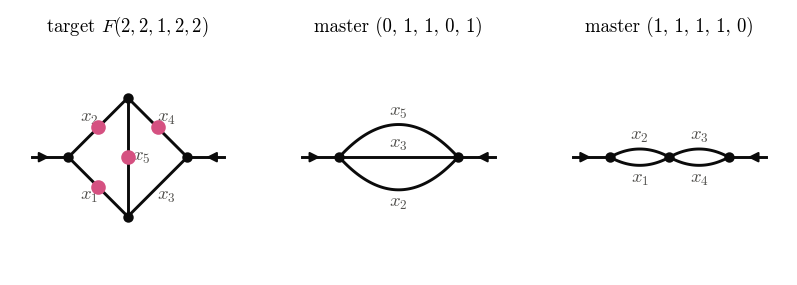

In [13]:
t0 = time.time()
exact = Reducer(famq, symmetries=[(2,3,0,1,4), (1,0,3,2,4)]).run(rmax=4, smax=2)
print("exact reducer (smaller seed range) time: %.1f s" % (time.time() - t0))
print("same coefficients:", all(exact.reduce((2,2,1,2,2))[m] == c for m, c in res[(2,2,1,2,2)].items()))
fig, axes = plt.subplots(1, 3, figsize=(6.6, 2.2))
draw_graph(kiteq, dots={1: 1, 2: 1, 4: 1, 5: 1}, ax=axes[0], momenta=False, title="target $F(2,2,1,2,2)$")
for ax, sec in zip(axes[1:], [(0,1,1,0,1), (1,1,1,1,0)]):
    h, kept = kiteq.contract([i + 1 for i in range(5) if not sec[i]])
    draw_graph(h, names=kept, ax=ax, momenta=False, title="master " + str(sec))

Shrinking lines 1 and 4 of the kite leaves three lines between two vertices, the sunset. Shrinking line 5
glues the two bubbles together at one vertex, so the second master is a product of two one-loop bubbles.

## 8. Closed one-loop formulas and the $\epsilon$ expansion

The module `oneloop` has the tadpole, the massless bubble $G(a, b)$, the on-shell triangle and the
massive bubbles in closed form, with $D = 4 - 2\epsilon$. `expand_eps` makes the Gamma-function poles
explicit before expanding.

As an example, the two-loop $\phi^4$ diagram of the notes is a massless bubble inserted into a triangle:
$G(1,1) \times T(1, 1, 2 - D/2)$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

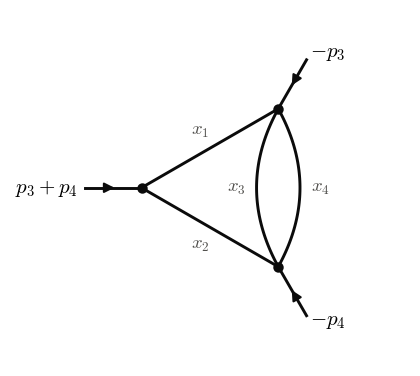

In [14]:
kf = Kinematics(['p3','p4'], ['Q2'], {('p3','p3'):0, ('p4','p4'):0, ('p3','p4'):'Q2/2'}, euclidean=True)
phi4 = FeynmanGraph([('A','B',0), ('A','C',0), ('B','C',0), ('B','C',0)],
                    {'A': mom(p3=1, p4=1), 'B': mom(p3=-1), 'C': mom(p4=-1)}, kf)
phi4.plot(figsize=(3, 3));
eq(r"\mathcal{U}", phi4.U()); eq(r"\mathcal{F}", phi4.F())
val = expand_eps(G(1,1) * triangle_onshell(1, 1, 2 - D/2, 1), 0, loops=2)
eq(r"\text{value at } Q^2 = 1", val)
eq(r"\text{tadpole, one propagator, } m^2 = 1", tadpole(1, 1))

## 9. Dirac traces with FORM

`form.trace` sends the trace to FORM (it must be on the `PATH`) and brings the answer back into Sage.

In [15]:
eq(r"\mathrm{Tr}[\gamma^\mu \gamma^\nu \gamma^\rho \gamma^\sigma]", form.trace(['mu', 'nu', 'rho', 'sigma']))

<IPython.core.display.Math object>

## 10. Plots in the style of the notes
11. A real number: the lifetime of the neutral pion

After `set_theme()` every matplotlib and Sage plot uses the fonts and colours of the notes.
`curves` draws several functions together and `mb_plane` draws the poles of a Mellin-Barnes integrand.

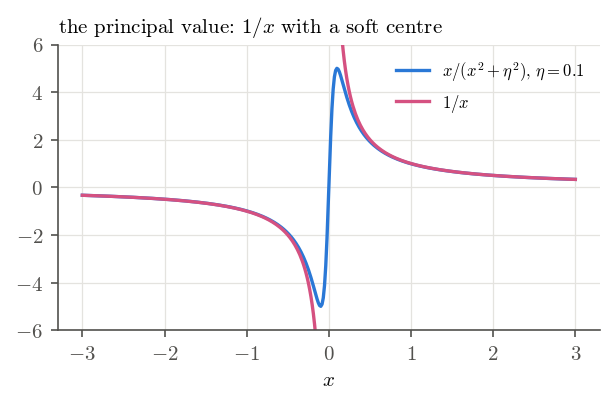

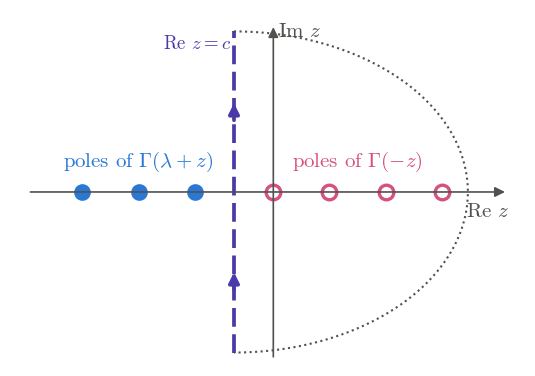

In [16]:
x = var('x')
curves([x/(x^2 + 0.1^2), 1/x], (-3, 3), labels=[r'$x/(x^2+\eta^2)$, $\eta = 0.1$', '$1/x$'], ylim=(-6, 6),
       title="the principal value: $1/x$ with a soft centre");
mb_plane([-1.4, -2.4, -3.4], [0, 1, 2, 3], -0.7, r'$\Gamma(\lambda+z)$', r'$\Gamma(-z)$', close='right');

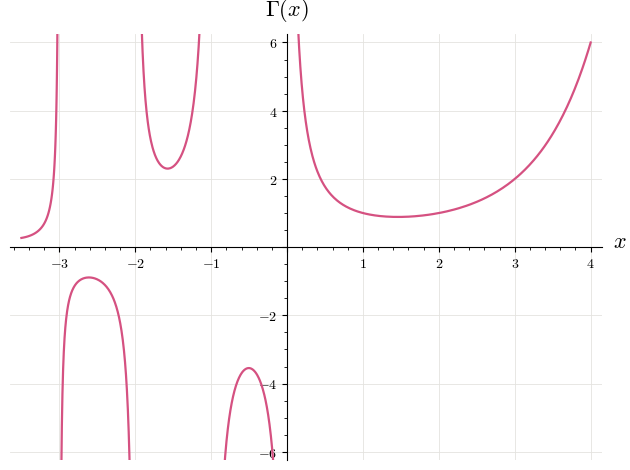

In [17]:
plot(gamma(x), (x, -3.5, 4), ymin=-6, ymax=6, color=PINK, thickness=1.6, detect_poles=True,
     axes_labels=['$x$', r'$\Gamma(x)$'], frame=False)

## 11. A real number: the lifetime of the neutral pion

The $\pi^0$ decays into two photons through a triangle of quarks and its lifetime has been measured to about
one per cent. Here is the whole prediction with the tools above. The physics is explained step by step in
the section *From a loop to a lifetime* of the notes.

The quarks $u$, $d$ (charges $2/3$, $-1/3$, $N_c$ colours) couple to the pion with $g\,\bar q\, i\gamma_5\tau_3\, q\,\pi^0$
and $g = m/f_\pi$. There are two diagrams per quark (the photons in either order). Below is the first one, drawn
by feynsage: a triangle of massive quark lines with the pion momentum entering at one corner.

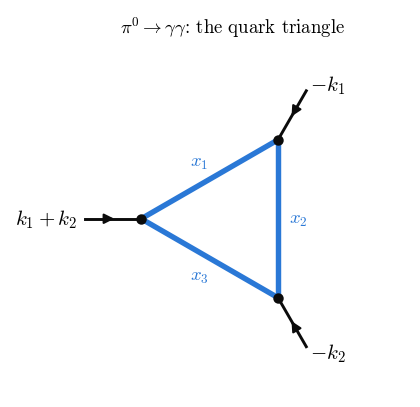

In [18]:
kp = Kinematics(['k1', 'k2'], ['mq'], {('k1','k1'): 0, ('k2','k2'): 0, ('k1','k2'): '1/2'}, euclidean=False)
tri = FeynmanGraph([('P','A','mq'), ('A','B','mq'), ('B','P','mq')],
                   {'P': mom(k1=1, k2=1), 'A': mom(k1=-1), 'B': mom(k2=-1)}, kp)
tri.plot(figsize=(3, 3), title=r"$\pi^0 \to \gamma\gamma$: the quark triangle");

**Step 1, the trace.** The quark runs P $\to$ A $\to$ B $\to$ P with momenta $\ell + k_1$, $\ell$, $\ell - k_2$
(the photon $k_1$ leaves at A, $k_2$ at B, and the pion brings $k_1 + k_2$ at P). The Dirac matrices are written
against the flow, starting at the pion vertex. A trace with $\gamma_5$ needs at least four other gamma matrices,
so only the terms with exactly one quark mass survive. FORM does it, with the loop momentum already shifted to
$\ell = q - x k_1 + y k_2$ (the Feynman shift of step 2):

In [19]:
# quark flow P -> A -> B -> P with momenta l + k1, l, l - k2; the trace runs against the flow, from P
T = form.dirac_trace(['g5', 'q - x*k1 - (1-y)*k2 + m', 'nu', 'q - x*k1 + y*k2 + m', 'mu',
                      'q + (1-x)*k1 + y*k2 + m'], vectors=['q', 'k1', 'k2'])
eq(r"\mathrm{Tr}", T)
print("(FORM's eps is -i times the usual epsilon)")

<IPython.core.display.Math object>

(FORM's eps is -i times the usual epsilon)


Nothing depends on $q$, $x$ or $y$, even before integrating: the $qq$ terms vanish because $\epsilon$ is antisymmetric
and the terms linear in $q$ cancel among themselves. So the usual symmetric-integration rules
($\int q^\mu/D^3 = 0$ and $q^\mu q^\nu \to g^{\mu\nu} q^2/4$) are not needed here. The numerator is the constant
$4m\,\epsilon^{\mu\nu k_1 k_2}$ and what is left is the scalar triangle.

**Step 2, the integral.** With Feynman parameters $x$ (line P-A) and $y$ (line B-P) the triangle gives $\Delta = m^2 - xy\,m_\pi^2$ (the cell below reads it off the graph) and

$$\int \frac{d^4\ell}{(2\pi)^4}\frac{1}{D_1D_2D_3} = \frac{-i}{16\pi^2 m^2}\, I(r), \qquad I(r) = \int_0^1\! dx\int_0^{1-x}\! dy\, \frac{1}{1 - xy\,r}, \qquad r = \frac{m_\pi^2}{m^2}$$

Expanding $1/(1 - xyr)$ in powers of $r$ gives $I(r) = \sum_n r^n\, n!^2/(2n+2)!$ term by term. We check that this is
$(2/r)\arcsin^2(\sqrt r/2)$ and that the heavy-quark limit is $1/2$.

$\Delta = \mathcal F/\mathcal U$ straight from the graph: the spanning trees give $\mathcal U = 1$ on the simplex, and
the only 2-forest that carries momentum is the one that cuts off the pion vertex, so $\mathcal F_0 = x y\, m_\pi^2$
with $x, y$ the parameters of the two lines that meet there.

In [20]:
# lines: 1 = P-A (l + k1), 2 = A-B (l), 3 = B-P (l - k2)
kt = Kinematics(['k1', 'k2'], ['mq', 'mpi2'], {('k1','k1'): 0, ('k2','k2'): 0, ('k1','k2'): 'mpi2/2'}, euclidean=False)
trig = FeynmanGraph([('P','A','mq^2'), ('A','B','mq^2'), ('B','P','mq^2')],
                    {'P': mom(k1=1, k2=1), 'A': mom(k1=-1), 'B': mom(k2=-1)}, kt)
U, F = trig.U(), trig.F()
eq(r"\mathcal{U}", U); eq(r"\mathcal{F}", F)
x1, x2, x3 = SR.var('x1 x2 x3')
eq(r"\mathcal{F}/\mathcal{U} \text{ on the simplex } (\mathcal{U} = 1)", SR(str(F)).subs(x2=1 - x1 - x3).expand())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [21]:
r, x, y = var('r x y')
n = 12
term_by_term = sum(r^k * integrate(integrate((x*y)^k, y, 0, 1 - x), x, 0, 1) for k in range(n))
closed = 2/r * arcsin(sqrt(r)/2)^2
eq(r"\text{series of the integral}", term_by_term.series(r, 4).truncate())
sv = var('s')                                   # r = 4 s^2 makes the closed form analytic in s
diff = (closed.subs(r=4*sv^2).taylor(sv, 0, 2*n - 2) - term_by_term.subs(r=4*sv^2)).expand()
eq(r"\text{closed form} - \text{series} \;(\text{up to } r^{%d})" % (n - 1), diff)
eq(r"\text{heavy-quark limit}", limit(closed, r=0))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Step 3, the amplitude.** One diagram gives $N_c\,(eQ)^2\, g \cdot 4m \cdot I/(16\pi^2 m^2)$, the crossed one the same.
With $g = m/f_\pi$ the quark mass cancels. For $m \gg m_\pi$ ($2I \to 1$) and $e^2 = 4\pi\alpha$ the $u$ and $d$
quarks give $A = N_c (Q_u^2 - Q_d^2)\, e^2/(4\pi^2 f_\pi)$.

**Step 4, the rate.** The polarisation sum gives $2(k_1\cdot k_2)^2 = m_\pi^4/2$, two-body phase space is
$1/(8\pi)$ and the photons are identical (a factor $1/2$), so $\Gamma = A^2 m_\pi^3/(64\pi)$.

In [22]:
Nc, alpha, f, mpi = var('N_c alpha f m_pi')
e2 = 4*pi*alpha
A = Nc * ((2/3)^2 - (-1/3)^2) * e2 / (4*pi^2*f)
Gamma = (A^2 * mpi^3 / (64*pi)).simplify_full()
eq(r"\Gamma(\pi^0 \to \gamma\gamma)", Gamma)
vals = {alpha: 1/137.035999, mpi: 134.9768, f: 130.2/sqrt(2)}      # MeV
hbar, BR = 6.582119569e-22, 0.98823                                  # MeV s, BR(gamma gamma)
G3 = (Gamma.subs(vals).subs({Nc: 3}) * 1e6).n()                         # eV
print("Gamma(pi0 -> gamma gamma) = %.2f eV     PrimEx-II (2020): 7.80 +- 0.12 eV" % G3)
print("lifetime = %.3g s          PDG: (8.43 +- 0.13)e-17 s" % (hbar * 1e6 * BR / G3))
print("with one colour: Gamma = %.2f eV, nine times too small" % (Gamma.subs(vals).subs({Nc: 1}) * 1e6).n())
print("finite constituent mass m = 330 MeV: 2 I(r) = %.4f" % (2*closed.subs(r=(134.9768/330)^2)).n())

<IPython.core.display.Math object>

Gamma(pi0 -> gamma gamma) = 7.79 eV     PrimEx-II (2020): 7.80 +- 0.12 eV
lifetime = 8.35e-17 s          PDG: (8.43 +- 0.13)e-17 s
with one colour: Gamma = 0.87 eV, nine times too small
finite constituent mass m = 330 MeV: 2 I(r) = 1.0143


One triangle of quarks gives the lifetime of the pion to about one per cent. The rate grows as $N_c^2$, so the
measurement also tells us that quarks come in three colours.

## 12. One-loop tensor integrals, the Package-X way

`loop(numerator, [momentum, mass], ...)` reduces any one-loop integral to $A_0$, $B_0$, $C_0$, $D_0$ in the
normalisation of Package-X and LoopTools. Numerators can have free indices ($\ell^\mu \ell^\nu$), scalar products
($\ell\cdot p$, $\ell^2$) and metric factors `g(mu,nu)`. Everything is exact: masses and invariants can stay symbols.
`explain=True` prints what the output means.

In [23]:
loop("l^mu l^nu", ["l", "m1"], ["l + p", "m2"], kin={"p^2": "s"}, explain=True)

loop(): a one-loop integral reduced to scalar functions.
  Normalisation (Package-X / LoopTools): mu^(2 eps) e^(eps gamma_E) Int d^d l/(i pi^(d/2)),
  d = 4 - 2 eps, propagators 1/(q^2 - m^2 + i0) [Minkowski] or, with euclidean=True,
  Int d^d l/pi^(d/2) with 1/(q^2 + m^2) [Euclidean; the functions are then the Minkowski
  ones at p_M^2 = -p_E^2 times (-1)^N].
  Output: one line per tensor structure (g^{mu nu}, p^mu, ... or 1 for a scalar numerator),
  each with its coefficient expanded to eps^0.  The pieces are
    1/eps^2, 1/eps  poles: UV, and IR (soft/collinear) from divergent C0, D0 written out,
    A0, B0      written out: logs, LogM(z) = log(z - i0), DiscB(s, m1, m2) (see B0?),
    C0(...), D0(...)  IR-finite ones stay symbols; .n() gives > 30 digits, explicit() the dilogarithms,
    mu          the renormalisation scale.
  .masters() gives the exact coefficients in d before expanding; .coefficients() a dict.


g^{mu nu} :  1/12*(m1^2 - m2^2 + s)*m1^2*(1/eps + log(mu^2/m1^2) + 1)/s - 1/12*(m1^2 - m2^2 - s)*m2^2*(1/eps + log(mu^2/m2^2) + 1)/s + 1/18*(m1^2 - m2^2 + s)*m1^2/s - 1/18*(m1^2 - m2^2 - s)*m2^2/s + 1/24*(m1^4 - 2*m1^2*m2^2 + m2^4 - 2*m1^2*s - 2*m2^2*s + s^2)*((m1^2 - m2^2 + s)*log(m1^2/m2^2)/s - 2/eps - 2*DiscB(s, m1, m2) - 2*log(mu^2/m2^2) - 4)/s - 1/18*(m1^4 - 2*m1^2*m2^2 + m2^4 - 2*m1^2*s - 2*m2^2*s + s^2)/s
p^mu p^nu :  -1/3*(m1^2 - m2^2 + s)*m1^2*(1/eps + log(mu^2/m1^2) + 1)/s^2 + 1/3*(m1^2 - m2^2 + 2*s)*m2^2*(1/eps + log(mu^2/m2^2) + 1)/s^2 - 1/18*(m1^2 - m2^2 + s)*m1^2/s^2 + 1/18*(m1^2 - m2^2 - s)*m2^2/s^2 - 1/6*(m1^4 - 2*m1^2*m2^2 + m2^4 + m1^2*s - 2*m2^2*s + s^2)*((m1^2 - m2^2 + s)*log(m1^2/m2^2)/s - 2/eps - 2*DiscB(s, m1, m2) - 2*log(mu^2/m2^2) - 4)/s^2 + 1/18*(m1^4 - 2*m1^2*m2^2 + m2^4 - 2*m1^2*s - 2*m2^2*s + s^2)/s^2

<IPython.core.display.Math object>

C0(0, 0, 5; 1, 1, 1) = -0.894334511878058 - 0.604708613771115*I
Euclidean, numerator l^2:


1 :  -m^2*(1/eps + DiscB(-P2, m, m) + log(mu^2/m^2) + 2) - m^2*(1/eps + log(mu^2/m^2) + 1)

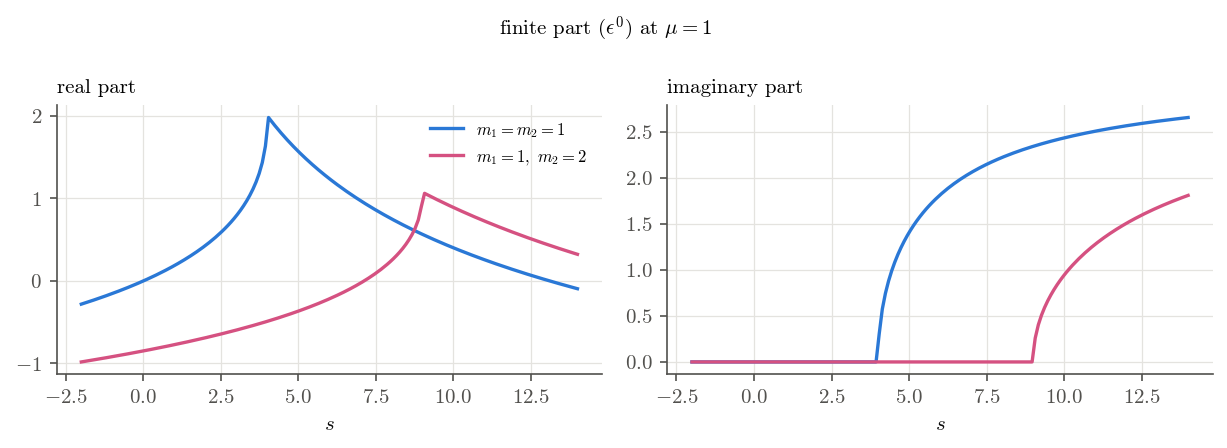

In [24]:
s, m = var('s m')
eq(r"B_{00}(s; m, m)", PVB(1, 0, s, m, m))
print("C0(0, 0, 5; 1, 1, 1) =", C0(0, 0, 5, 1, 1, 1).n())
print("Euclidean, numerator l^2:")
display(loop("l^2", ["l", "m"], ["l + p", "m"], kin={"p^2": "P2"}, euclidean=True))
quick_plot([B0(s, 1, 1), B0(s, 1, 2)], (s, -2, 14), labels=["$m_1 = m_2 = 1$", "$m_1 = 1,\\ m_2 = 2$"]);

These functions agree with Package-X 2.1.1 at 190 kinematic points, including all thresholds
(`tests/test_pv.sage`): $A_0$, $B_0$ and the $B$ tensors to machine precision, the $C$ tensors to machine precision and $C_0$, $D_0$ to about 37 digits.

## 13. The four examples of the lecture notebook

Sir's notebook `uf-new-short.nb` finds $\mathcal U$ and $\mathcal F$ by completing the square. feynsage gets
the same polynomials from the propagators and, independently, from the graph (`tests/test_professor_uf.sage`):

In [25]:

examples = {   # name: (family, the lecture notebook's U, F)
  "triangle": (family(["k", "k + p1", "k + p1 + p2"], kin={"p1^2": "P1Sq", "p2^2": "P2Sq", "p1.p2": "(QSq - P1Sq - P2Sq)/2"}),
               "x1 + x2 + x3", "-P1Sq*x1*x2 - QSq*x1*x3 - P2Sq*x2*x3"),
  "bubble":   (family([("k", "m1"), ("k + p1", "m2")], kin={"p1^2": "p1sq"}),
               "x1 + x2", "m1^2*x1^2 + m1^2*x1*x2 + m2^2*x1*x2 - p1sq*x1*x2 + m2^2*x2^2"),
  "box":      (family(["k", "k + p1", "k + p1 + p2", "k - p3"],
                      kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p1.p3": "t/2", "p2.p3": "-(s+t)/2"}),
               "x1 + x2 + x3 + x4", "-s*x1*x3 - t*x2*x4"),
  "sunset":   (family([("k", "m"), ("k - l", "m"), ("l + p", "m")], kin={"p^2": "x*m^2"}),
               "x2*x3 + x1*(x2 + x3)", "m^2*(x1^2*(x2 + x3) + x2*x3*(x2 + x3) + x1*(x2^2 - (-3 + x)*x2*x3 + x3^2))"),
}
for name, (fam, Uref, Fref) in examples.items():
    U, F = fam.UF()
    R = U.parent()
    print("%s: same as the lecture notebook: %s" % (name, U == R(Uref) and F == R(Fref)))
    eq(r"\mathcal{U}", U); eq(r"\mathcal{F}", F)


triangle: same as the lecture notebook: True


<IPython.core.display.Math object>

<IPython.core.display.Math object>

bubble: same as the lecture notebook: True


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

sunset: same as the lecture notebook: True


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 14. The short front end

For everyday use there are string-based helpers. `family` builds an integral family, `ibp_reduce` chooses the
seeds, finds the symmetries itself (automorphisms of $\mathcal U + \mathcal F$) and picks the fastest reducer,
`diagram` gives named diagrams and `quick_plot` plots any expression.

In [26]:
kite = family(["l1", "l1 + q", "l1 + l2", "l1 + l2 + q", "l2"], kin={"q^2": 1})
kite.info()
print("symmetries found:", symmetries(kite))
res = ibp_reduce(kite, ["F(1,1,1,1,1)", "F(2,2,1,2,2)"])
res

Integral family 'F'
  loop momenta: l1, l2   external momenta: q   Minkowski metric
  D1 = (l1)^2
  D2 = (l1 + q)^2
  D3 = (l1 + l2)^2
  D4 = (l1 + l2 + q)^2
  D5 = (l2)^2
  An integral F(a1,...,at) is  Int prod_r d^d l_r  prod_i D_i^(-a_i); a_i <= 0 are numerators.
symmetries found: [(1, 0, 3, 2, 4), (2, 3, 0, 1, 4)]


F(1, 1, 1, 1, 1) = [(-2) * (d - 4)^-1 * (d - 3)] F(1, 1, 1, 1, 0) + [(18) * (d - 4)^-2 * (d - 10/3) * (d - 8/3)] F(0, 1, 1, 0, 1)
F(2, 2, 1, 2, 2) = [(-729) * (d - 8)^-2 * (d - 10)^-1 * (d - 4)^-1 * (d - 7) * (d - 16/3) * (d - 14/3) * (d - 10/3) * (d - 8/3) * (d^2 - 11*d + 20)] F(0, 1, 1, 0, 1) + [(-4) * (d - 8)^-1 * (d - 9) * (d - 6) * (d - 5) * (d - 3)] F(1, 1, 1, 1, 0)

tadpole      one massive line from a vertex back to itself
bubble       massless bubble, p^2 = s
bubble_mass  equal-mass bubble
triangle     massless triangle with three off-shell legs
box          massless box, on-shell legs, s and t
sunset       two-loop sunset, three equal masses
kite         two-loop massless kite
phi4_two     two-loop phi^4 diagram of the notes


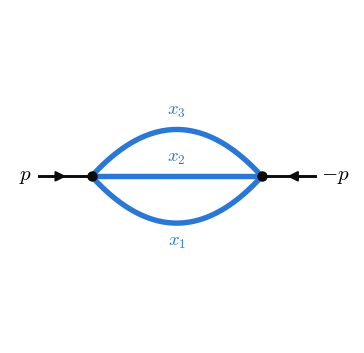

In [27]:
diagram()                          # the list of named diagrams
diagram("sunset").plot();

## 15. Poles from soft photons, boxes in dilogarithms, and a zero Gram determinant

Three things that used to stop a calculation now just work.

* **IR poles.** A massless line between two on-shell legs (a soft photon) or between two massless
  legs (collinear) makes $C_0$ or $D_0$ divergent. `C0(...)` and `D0(...)` then return
  $c_{-2}/\epsilon^2 + c_{-1}/\epsilon + c_0$ directly (Ellis and Zanderighi's 6 triangles and 16 boxes,
  any order of the lines). `loop()`, `PVC` and `PVD` carry these poles through the reduction.
* **Closed forms.** A finite $D_0$ stays a symbol; `.n()` gives about 30 digits and `explicit()`
  writes it with 16 dilogarithms (fewer when lines are massless).
* **Gram determinant zero.** At $q^2 = 0$ in the $g-2$ vertex, or with all invariants zero, the usual
  reduction divides by zero. feynsage then takes the coefficients straight from Feynman parameters, exactly.

In [28]:
# QED vertex with a massless photon, electrons on shell: m = 1, q^2 = -3
v = C0(1, -3, 1, 0, 1, 1)
print("vertex C0:  1/eps coefficient %s,  finite part %s" % (pole_parts(v)[1].n(digits=12), finite_part(v, 1).n(digits=12)))

# the massless box has double poles
eq(r"D_0(0,0,0,0;-2,-3;0,0,0,0)", D0(0, 0, 0, 0, -2, -3, 0, 0, 0, 0))

# a finite box: a symbol, its number, its closed form
d = D0(1, 2, 3, 4, -5, -6, 1, 1, 1, 1)
print(d, "=", d.n(digits=15), "  (closed form:", len(str(explicit(d))), "characters)")

# g-2 vertex at q^2 = 0: the Gram determinant vanishes
m = var('m')
eq(r"C_1(m^2, 0, m^2; 0, m, m)", PVC(0, 1, 0, m^2, 0, m^2, 0, m, m))
eq(r"C_{00}(m^2, 0, m^2; 0, m, m)", PVC(1, 0, 0, m^2, 0, m^2, 0, m, m).log_expand().expand())

vertex C0:  1/eps coefficient 0.341903623916,  finite part -0.125244269255


<IPython.core.display.Math object>

D0(1, 2, 3, 4, -5, -6, 1, 1, 1, 1) = 0.272791904367968   (closed form: 8852 characters)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

The checks are in `tests/test_ir.sage`, `tests/test_d0.sage` and `tests/test_ir_tensor.sage`.
They compare with Package-X at more than 400 points, and use a photon mass where Package-X gives no number.
One of Package-X's own values turned out to be wrong: its $C_0(-4,-3,-1;0,0,1) = +0.671$, but with all
invariants spacelike $C_0$ must be negative. Direct integration gives $-0.585977$, as feynsage does.

## 16. Exact IBP reduction made fast

Laporta with exact rational functions in $d$ is slow because it eliminates *every* seeded equation,
although the targets need only a few of them. `method="trimmed"` first does one elimination modulo a
large prime at a random point, keeps only the equations the targets need, and then runs the exact
reduction on those. The arithmetic stays exact (no sampling, no reconstruction).

In [29]:
kite = family(["l1", "l1 + q", "l1 + l2", "l1 + l2 + q", "l2"], kin={"q^2": 1})
res = {}
for method in ["ff", "trimmed", "exact"]:
    res[method] = ibp_reduce(kite, ["F(2,2,1,2,2)"], method=method)
    print("%-8s %6.2f s" % (method, res[method].seconds))
print("trimmed = finite fields:", res["trimmed"].table == res["ff"].table,
      "   trimmed = exact:", res["trimmed"].table == res["exact"].table)
res["trimmed"]

ff         0.12 s


trimmed    0.10 s


exact      4.92 s
trimmed = finite fields: True    trimmed = exact: True


F(2, 2, 1, 2, 2) = [(-4) * (d - 8)^-1 * (d - 9) * (d - 6) * (d - 5) * (d - 3)] F(1, 1, 1, 1, 0) + [(-729) * (d - 8)^-2 * (d - 10)^-1 * (d - 4)^-1 * (d - 7) * (d - 16/3) * (d - 14/3) * (d - 10/3) * (d - 8/3) * (d^2 - 11*d + 20)] F(0, 1, 1, 0, 1)

For the big system of the README (seeds up to 9 dots and 4 numerator powers, 157 843 equations,
target $F(3,3,2,3,3)$), on one server:

| method | time |
|---|---|
| exact, all equations | 11 min (280 MB) |
| exact, trimmed (859 equations kept) | 8.6 s |
| finite fields | 11.7 s |

All three give the same coefficients (`slides/bench_exact.sage`).

## 17. $\mathcal U$ and $\mathcal F$ beyond the lecture notebook

Sir's notebook completes the square loop by loop, $\mathcal U = \det M$ and
$\mathcal F = \det M\,(J - Q^T M^{-1} Q)$, for diagrams up to two loops. The same polynomials come from
the graph itself. Here is the three-loop *triple box*, done three independent ways: spanning trees
and 2-forests, the Kirchhoff matrix-tree theorem and $\det M$ from the propagators.

56 spanning trees; U has 56 terms, F has 65   (0.02 s)
Kirchhoff = trees: True    det M = trees: True


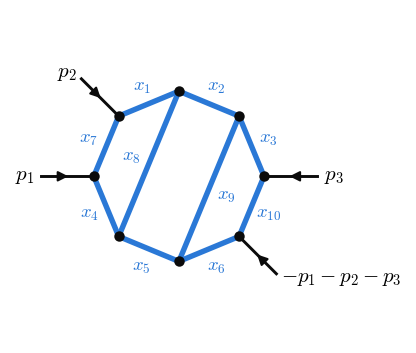

In [30]:
tb = graph("T1-T2, T2-T3, T3-T4, B1-B2, B2-B3, B3-B4, T1-B1, T2-B2, T3-B3, T4-B4",
           {"B1": "p1", "T1": "p2", "T4": "p3", "B4": "-p1 - p2 - p3"},
           kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p2.p3": "t/2", "p1.p3": "-(s+t)/2"})
t0 = time.time()
U, F = tb.U(), tb.F()                                   # trees and 2-forests
Uk = tb.U_kirchhoff()                                   # matrix-tree theorem
props, loops = tb.family()
Um, Fm = IntegralFamily("tb", loops, tb.kin, props).UF()  # det M, from the propagators
print("%d spanning trees; U has %d terms, F has %d   (%.2f s)" % (len(tb.spanning_trees()), len(U.monomials()), len(F.monomials()), time.time() - t0))
print("Kirchhoff = trees:", Uk == U, "   det M = trees:", tb.R(str(Um)) == U and tb.R(str(Fm)) == F)
tb.plot();

FeynCalc's `FCFeynmanPrepare` gives exactly the same polynomials for this diagram, the kite, the
double box and the three-loop banana (`slides/uf_extend.sage`).

## 18. QED from Chluba's thesis

J. Chluba, *Spectral distortions of the cosmic microwave background* (2005), uses Compton and double
Compton scattering, and meets the infrared divergence of double Compton emission. Here everything is
computed from the Feynman diagrams, with FORM for the Dirac traces. The same calculations in FeynCalc
are in `examples/chluba/`; they agree.

### 18.1 Compton scattering

![Compton scattering](figs/compton.svg)

$e(P) + \gamma(K) \to e(P') + \gamma(K')$, with $m = 1$ and exact rational kinematics. The sum over spins
and polarisations of $|\mathcal M|^2$ is compared with the textbook formula; from it come Klein–Nishina and the
Thomson cross section.

In [31]:
dot_ = function('dot'); m = var('m')
def ev(expr, table):
    """Put numbers into the scalar products of a FORM result (m = 1)."""
    return expr.substitute_function(dot_, lambda a, b: table[tuple(sorted((str(a), str(b))))]).subs(m=1).expand()

def compton_table(pk, pkp):                       # P' = P + K - K'
    kkp = pk - pkp
    t = {('p','p'): 1, ('k','k'): 0, ('kp','kp'): 0, ('k','p'): pk, ('kp','p'): pkp, ('k','kp'): kkp,
         ('p','pp'): 1 + pk - pkp, ('k','pp'): pk - kkp, ('kp','pp'): pkp + kkp, ('pp','pp'): 1}
    return {tuple(sorted(k)): v for k, v in t.items()}

def compton_msq(pk, pkp):
    """sum over spins and polarisations of |M|^2 / e^4: s- and u-channel, (chain, conjugate, denominator)."""
    tab = compton_table(pk, pkp)
    ch = [(["nu", "p + k + m", "mu"], ["mu", "p + k + m", "nu"], 2*pk),
          (["mu", "p - kp + m", "nu"], ["nu", "p - kp + m", "mu"], -2*pkp)]
    return sum(ev(form.dirac_trace(["pp + m"] + a + ["p + m"] + bc, vectors=["p", "pp", "k", "kp"]), tab) / (da*db)
               for a, _, da in ch for _, bc, db in ch)

pk, pkp = 3/7, 2/9
sm, um = 2*pk, -2*pkp                             # s - m^2 and u - m^2
textbook = 8*(-um/sm - sm/um + 4*(1/sm + 1/um) + 4*(1/sm + 1/um)^2)
print("sum |M|^2/e^4 =", compton_msq(pk, pkp), "   textbook 8[...] =", textbook)

# lab frame: s - m^2 = 2 w, u - m^2 = -2 w', w' = w/(1 + w(1 - cos theta))
w, c, alpha = var('w c alpha')
wp = w/(1 + w*(1 - c))
avg = 8*(-(-2*wp)/(2*w) - (2*w)/(-2*wp) + 4*(1/(2*w) + 1/(-2*wp)) + 4*(1/(2*w) + 1/(-2*wp))^2)/4
dsig = (wp/w)^2*avg*(4*pi*alpha)^2/(64*pi^2)
kn = alpha^2/2*(wp/w)^2*(wp/w + w/wp - (1 - c^2))
print("Klein-Nishina:", bool((dsig - kn).simplify_full() == 0),
      "   Thomson limit sigma =", integrate(kn.subs(w=0)*2*pi, c, -1, 1), "(r0 = alpha/m)")

sum |M|^2/e^4 = 4246/189    textbook 8[...] = 4246/189


Klein-Nishina: True    Thomson limit sigma = 8/3*pi*alpha^2 (r0 = alpha/m)


### 18.2 Double Compton scattering: six diagrams

![The six double Compton diagrams](figs/dc.svg)

$e(P) + \gamma(K_0) \to e(P') + \gamma(K_1) + \gamma(K_2)$. The three photons attach to the electron line in
all $3! = 6$ orders; with the incoming photon written as an outgoing one of momentum $-K_0$ the six
chains are generated together. The thesis quotes Mandl & Skyrme's result as $|\mathcal M|^2 = e^6 X$
(its eq. D.1).

In [32]:
V = ['p', 'pp', 'k0', 'k1', 'k2']

def dc_table(pk0, pk1, pk2, k0k1, k0k2):
    """Scalar products for e(P) + g(K0) -> e(P') + g(K1) + g(K2), m = 1; P' on shell fixes K1.K2."""
    k1k2 = -(pk0 - pk1 - pk2 - k0k1 - k0k2)
    t = {('p','p'): 1, ('k0','k0'): 0, ('k1','k1'): 0, ('k2','k2'): 0, ('k0','p'): pk0, ('k1','p'): pk1,
         ('k2','p'): pk2, ('k0','k1'): k0k1, ('k0','k2'): k0k2, ('k1','k2'): k1k2}
    d = lambda a, b: t[tuple(sorted((a, b)))]
    pp = {'p': 1, 'k0': 1, 'k1': -1, 'k2': -1}
    for v in ['p', 'k0', 'k1', 'k2']:
        t[tuple(sorted(('pp', v)))] = sum(cc*d(u, v) for u, cc in pp.items())
    t[('pp','pp')] = sum(c1*c2*d(u1, u2) for u1, c1 in pp.items() for u2, c2 in pp.items())
    return {tuple(sorted(k)): v for k, v in t.items()}

def square(expr, tab):
    """(momentum)^2 - m^2 for a combination like 'pp + -k0' or 'p - (k1)'."""
    e = SR(expr.replace('pp', 'PPx'))
    co = {v: e.coefficient(SR('PPx' if v == 'pp' else v)) for v in V}
    return sum(co[a]*co[b]*tab[tuple(sorted((a, b)))] for a in V for b in V) - 1
for v in V + ['PPx']:
    SR.var(v)

def dc_msq(tab):
    """sum over spins and polarisations of |M|^2 / e^6, all six diagrams."""
    ph = {'a': ('-k0', 'mu1'), 'b': ('k1', 'mu2'), 'c': ('k2', 'mu3')}
    chains = []
    for o in itertools.permutations('abc'):
        (q1, i1), (q2, i2), (q3, i3) = (ph[x] for x in o)
        chains.append(([i1, 'pp + %s + m' % q1, i2, 'p - (%s) + m' % q3, i3],
                       square('pp + %s' % q1, tab) * square('p - (%s)' % q3, tab)))
    tot = 0
    for c1, d1 in chains:
        for c2, d2 in chains:
            tot += ev(form.dirac_trace(['pp + m'] + c1 + ['p + m'] + c2[::-1], vectors=V), tab) / (d1*d2)
    return -tot                                    # (-g) for each of the three photons

def mandl_skyrme_X(tab):
    d = lambda a, b: tab[tuple(sorted((a, b)))]
    k0, k1, k2 = -d('p','k0'), d('p','k1'), d('p','k2')
    k0p, k1p, k2p = d('pp','k0'), -d('pp','k1'), -d('pp','k2')
    a = 1/k0 + 1/k1 + 1/k2; b = 1/k0p + 1/k1p + 1/k2p; cc = 1/(k0*k0p) + 1/(k1*k1p) + 1/(k2*k2p)
    x = k0 + k1 + k2; z = k0*k0p + k1*k1p + k2*k2p; A = k0*k1*k2; B = k0p*k1p*k2p
    rho = k0/k0p + k0p/k0 + k1/k1p + k1p/k1 + k2/k2p + k2p/k2
    return (2*(a*b - cc)*((a + b)*(2 + x) - (a*b - cc) - 8) - 2*x*(a^2 + b^2) - 2*(a*b + cc*(1 - x))*rho - 8*cc
            + 4*x/(A*B)*((A + B)*(1 + x) + x^2*(1 - z) + 2*z - (a*A + b*B)*(2 + (1 - x)*z/x)))

import itertools
for pt in [(7/3, 26/25, 4/7, 35/8, 24/23), (4/21, 7/3, 1/3, 27/7, 16/7)]:
    t0 = time.time(); tab = dc_table(*pt)
    print("kinematics", pt, "  sum|M|^2 / (e^6 X) =", dc_msq(tab) / mandl_skyrme_X(tab), "  (%.1f s)" % (time.time() - t0))

kinematics (7/3, 26/25, 4/7, 35/8, 24/23)   sum|M|^2 / (e^6 X) = 4   (0.6 s)


kinematics (4/21, 7/3, 1/3, 27/7, 16/7)   sum|M|^2 / (e^6 X) = 4   (0.6 s)


Exactly 4 at every point: the thesis's $|\mathcal M|^2 = e^6 X$ is the average over the $2\times 2$ spins and
polarisations of the initial electron and photon.

### 18.3 The infrared divergence

![a soft photon from an external electron](figs/soft.svg)

When $K_2 \to 0$ double Compton factorises into Compton scattering times the *eikonal factor*
$$S = \frac{2P\cdot P'}{(P\cdot K_2)(P'\cdot K_2)} - \frac{m^2}{(P\cdot K_2)^2} - \frac{m^2}{(P'\cdot K_2)^2} \propto \frac{1}{\omega_2^2},$$
so $d\sigma \propto d\omega_2/\omega_2$: the divergence of the thesis (its sec. 4.4.5). Below, $K_2$ is scaled by $\lambda$.

In [33]:
pk0, pk1, pk2, k0k2 = 3/4, 1/3, 1/2, 1/3
for lam in [1/10^4, 1/10^6, 1/10^8]:
    tab = dc_table(pk0, pk1, lam*pk2, pk0 - pk1 - lam/5, lam*k0k2)        # P'.K2 = lam/5
    d = lambda a, b: tab[tuple(sorted((a, b)))]
    S = 2*d('p','pp')/(d('p','k2')*d('pp','k2')) - 1/d('p','k2')^2 - 1/d('pp','k2')^2
    print("lambda = %g:   sum|M_DC|^2 / (S sum|M_C|^2) = %.10f" % (lam, dc_msq(tab) / (S*compton_msq(pk0, pk1))))

lambda = 0.0001:   sum|M_DC|^2 / (S sum|M_C|^2) = 0.9969856372


lambda = 1e-06:   sum|M_DC|^2 / (S sum|M_C|^2) = 0.9999698113


lambda = 1e-08:   sum|M_DC|^2 / (S sum|M_C|^2) = 0.9999996981


Integrated over the photon's direction, one soft photon comes with
$dN = \frac{\alpha}{\pi}\, I(t)\, \frac{d\omega_2}{\omega_2}$, where
$I(t) = 2P\cdot P' \int_0^1 \frac{dx}{m^2 - x(1-x)t} - 2$ and $t = (P - P')^2$.
For cold electrons and soft photons $-t = 2\omega_0^2(1 - \cos\theta)$ is small; averaged over Thomson scattering
this gives Lightman's law (thesis eq. 4.24):

In [34]:
x_, t_, c_, w0 = var('x_ t_ c_ w0')
Iser = (2*(1 - t_/2)*integrate((1/(1 - x_*(1 - x_)*t_)).series(t_, 3).truncate(), x_, 0, 1) - 2).series(t_, 2).truncate()
thomson = 1 + c_^2
avg = integrate(Iser.subs(t_=-2*w0^2*(1 - c_))*thomson, c_, -1, 1) / integrate(thomson, c_, -1, 1)
eq("I(t)", Iser)
eq(r"\langle I \rangle_{\rm Thomson}", avg)
print("so dN/d omega_2 = (alpha/pi) * %s / omega_2 = (4 alpha / 3 pi) omega_0^2 / omega_2" % avg)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

so dN/d omega_2 = (alpha/pi) * 4/3*w0^2 / omega_2 = (4 alpha / 3 pi) omega_0^2 / omega_2


### 18.4 Regularisation: the divergence cancels

![the virtual soft photon and the vertex that carries its pole](figs/virtual.svg)

The thesis stops the divergence with a lowest frequency $\nu_{2,\min}$. In $D = 4 - 2\epsilon$ a real soft photon
(energy below $\Delta E$) gives $d\sigma_C\,(-\alpha I(t)/2\pi\epsilon)$. The virtual soft photon between the electron legs
has the same infrared pole as the one-loop QED vertex at $t = (P-P')^2$; with $\Gamma^\mu = F_1\gamma^\mu + \dots$ the cross
section gets $2\,\mathrm{Re}\,F_1$. So the IR pole of $F_1$ must be $+\alpha I(t)/4\pi\epsilon$. The UV pole does not depend on $t$,
so differences between two values of $t$ isolate the IR part. $F_2 \to \alpha/2\pi$ checks the normalisation.

In [35]:
D_ = SR.var('D')
def trace_D(factors):
    return form.dirac_trace(factors, vectors=['p', 'pp', 'l'], dim='D').subs(m=1)
num_g = trace_D(['p + m', 'mu', 'pp + m', 'nu', 'pp + l + m', 'mu', 'p + l + m', 'nu'])     # projected on gamma_mu
num_P = trace_D(['p + m', 'pp + m', 'nu', 'pp + l + m', 'p + pp', 'p + l + m', 'nu'])       # on (P + P')_mu

def tree(factors, tv):
    tab = {('p','p'): 1, ('pp','pp'): 1, ('p','pp'): 1 - tv/2}
    e = form.dirac_trace(factors, vectors=['p', 'pp'], dim='D').subs(m=1)
    return e.substitute_function(dot_, lambda a, b: tab.get((str(a), str(b)), tab.get((str(b), str(a))))).expand()

def form_factors(tv):
    """F1, F2 of the one-loop vertex in units alpha/(4 pi), expanded to eps^0."""
    kin = {"p^2": 1, "pp^2": 1, "p.pp": 1 - tv/2}
    vs = [SR(loop(form.to_loop(n).replace('D', 'd'), ["l", "0"], ["l + pp", "1"], ["l + p", "1"], kin=kin)["1"])
          for n in (num_g, num_P)]
    Mx = matrix(SR, [[tree(['p + m', 'mu', 'pp + m', 'mu'], tv), tree(['p + m', 'p + pp', 'pp + m'], tv)/2],
                     [tree(['p + m', 'pp + m', 'p + pp'], tv), tree(['p + m', 'pp + m'], tv)*(4 - tv)/2]]).subs({D_: 4 - 2*eps})
    A, B = Mx.solve_right(vector(SR, vs))                  # Gamma = A gamma^mu + B (P + P')^mu / 2m
    return (A + B).series(eps, 1).truncate().expand(), (-B).series(eps, 1).truncate().expand()

import mpmath
I_ang = lambda tv: 2*(1 - tv/2)*mpmath.quad(lambda x: 1/(1 - x*(1 - x)*tv), [0, 1]) - 2
pole = lambda tv: form_factors(tv)[0].subs(mu=1).coefficient(eps, -1)
p0 = pole(-1/2)
for tv in [-1, -3, -8]:
    print("t = %3s:  pole of F1(t) - F1(-1/2) = %.12f    I(t) - I(-1/2) = %.12f"
          % (tv, (pole(tv) - p0).n(), float(I_ang(float(tv)) - I_ang(-0.5))))
F2 = form_factors(-1/10^6)[1].subs(mu=1).coefficient(eps, 0)
print("F2 at t = -1e-6:", F2.real_part().n(digits=10), "x alpha/(4 pi), i.e. alpha/(2 pi)")

t =  -1:  pole of F1(t) - F1(-1/2) = 0.271963043918    I(t) - I(-1/2) = 0.271963043918


t =  -3:  pole of F1(t) - F1(-1/2) = 1.108545637288    I(t) - I(-1/2) = 1.108545637288


t =  -8:  pole of F1(t) - F1(-1/2) = 2.368915948651    I(t) - I(-1/2) = 2.368915948651


F2 at t = -1e-6: 1.999999667 x alpha/(4 pi), i.e. alpha/(2 pi)


The real and virtual poles cancel: in dimensional regularisation (or with a photon mass) the lowest-frequency
cutoff of the thesis becomes a logarithm of the energy resolution $\Delta E$ (Bloch–Nordsieck).
The IR pole of the vertex here comes from the soft triangle $C_0(m^2, t, m^2; 0, m, m)$, which `loop()` expands with
its poles written out (step 15).